In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the data
march = pd.read_csv('dailyActivity_march.csv')
april = pd.read_csv('dailyActivity_april.csv')
sleep = pd.read_csv('sleepDay.csv')

In [ ]:
# Preview the data
march.head()

SyntaxError: invalid syntax (1244540069.py, line 1)

In [5]:
# Preview the data
march.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886


In [6]:
# Check sizes
print("March rows:", march.shape[0])
print("April rows:", april.shape[0])

# Combine into one DataFrame
activity = pd.concat([march, april], ignore_index=True)
print("Combined rows:", activity.shape[0])


March rows: 457
April rows: 940
Combined rows: 1397


In [7]:
# Remove duplicates based on Id and ActivityDate
activity = activity.drop_duplicates(subset=['Id', 'ActivityDate'])
print("After removing duplicates:", activity.shape[0])

# Remove zero step rows
activity = activity[activity['TotalSteps'] > 0]
print("After removing zero steps:", activity.shape[0])


After removing duplicates: 1373
After removing zero steps: 1235


In [8]:
# Clean sleep data
sleep = sleep.drop_duplicates(subset=['Id', 'SleepDay'])
print("Sleep rows after cleaning:", sleep.shape[0])


Sleep rows after cleaning: 410


In [9]:
# Summary statistics
activity[['TotalSteps', 'Calories', 'SedentaryMinutes', 
          'LightlyActiveMinutes', 'FairlyActiveMinutes', 
          'VeryActiveMinutes']].describe()

,TotalSteps,Calories,SedentaryMinutes,LightlyActiveMinutes,FairlyActiveMinutes,VeryActiveMinutes
count,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000
mean,8057.187045,2336.370040,951.690688,205.238866,14.476923,21.666397
std,4868.767797,731.963868,291.848632,101.417692,20.666764,32.686624
min,4.000000,50.000000,0.000000,0.000000,0.000000,0.000000
25%,4497.500000,1843.000000,718.000000,141.000000,0.000000,0.000000
50%,7623.000000,2203.000000,1011.000000,206.000000,8.000000,5.000000
75%,10989.000000,2818.500000,1189.000000,270.000000,21.000000,32.500000
max,36019.000000,4900.000000,1440.000000,720.000000,143.000000,210.000000


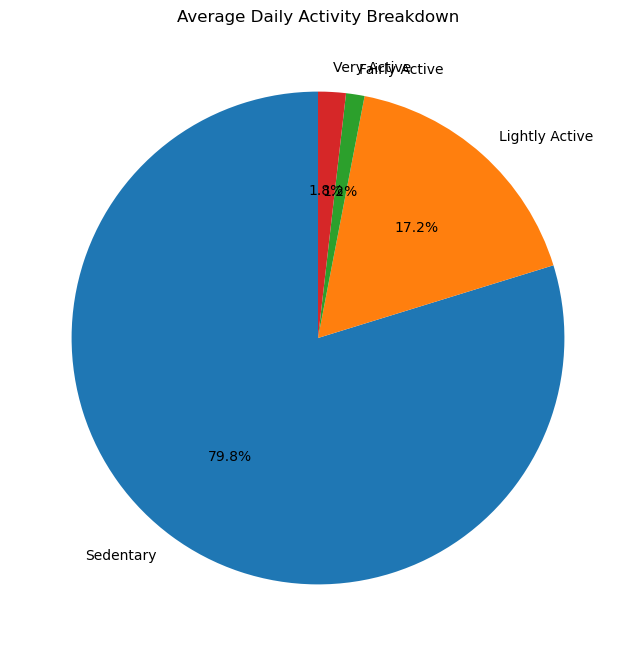

In [10]:
# Activity breakdown pie chart
labels = ['Sedentary', 'Lightly Active', 'Fairly Active', 'Very Active']
values = [
    activity['SedentaryMinutes'].mean(),
    activity['LightlyActiveMinutes'].mean(),
    activity['FairlyActiveMinutes'].mean(),
    activity['VeryActiveMinutes'].mean()
]

plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Average Daily Activity Breakdown')
plt.show()


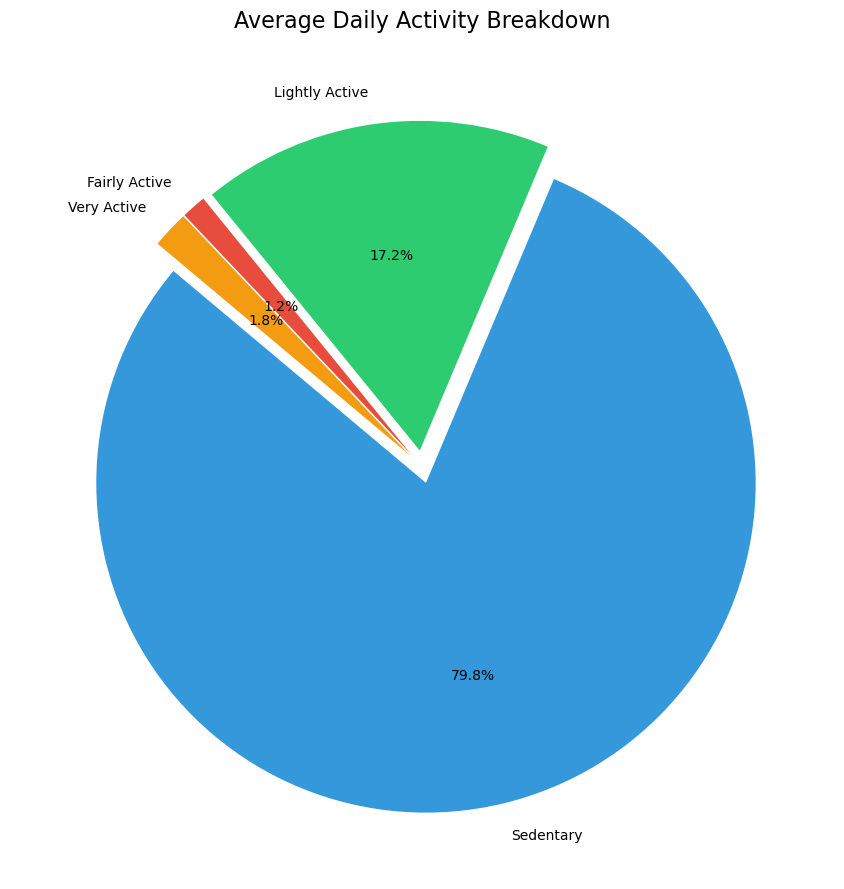

In [11]:
plt.figure(figsize=(9, 9))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'],
        explode=[0.05, 0.05, 0.05, 0.05])
plt.title('Average Daily Activity Breakdown', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

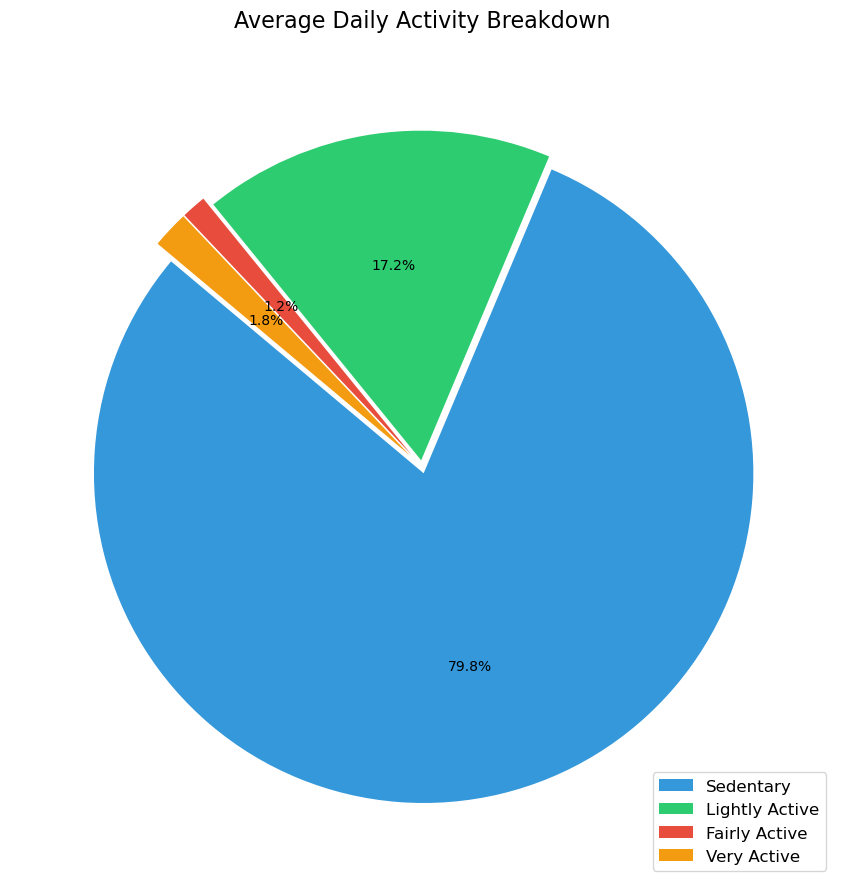

In [12]:
plt.figure(figsize=(9, 9))
plt.pie(values, autopct='%1.1f%%', startangle=140,
        colors=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'],
        explode=[0.02, 0.02, 0.05, 0.05])
plt.title('Average Daily Activity Breakdown', fontsize=16, pad=20)
plt.legend(labels, loc='lower right', fontsize=12)
plt.tight_layout()
plt.show()

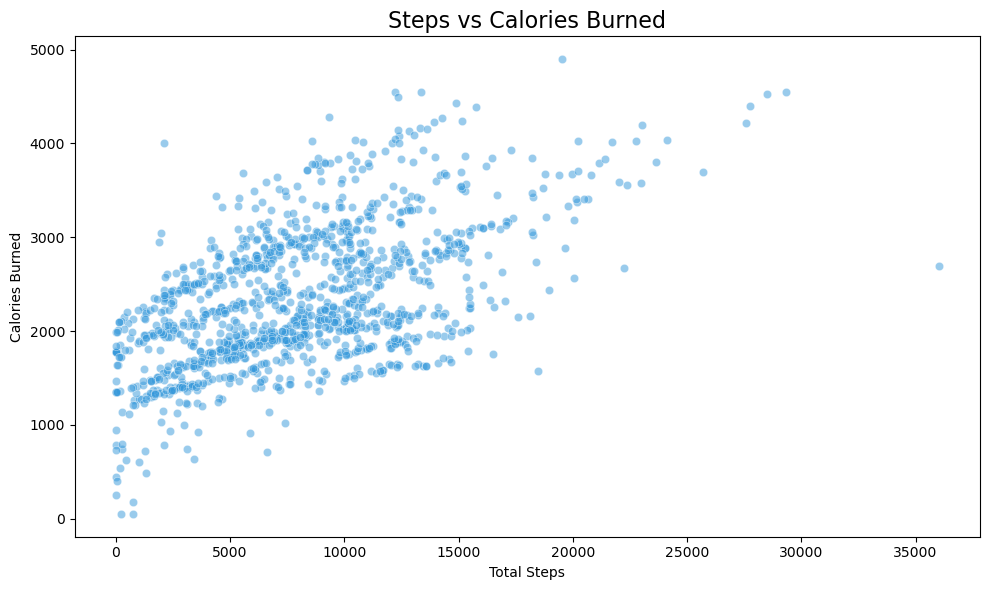

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=activity, x='TotalSteps', y='Calories', alpha=0.5, color='#3498db')
plt.title('Steps vs Calories Burned', fontsize=16)
plt.xlabel('Total Steps')
plt.ylabel('Calories Burned')
plt.tight_layout()
plt.show()

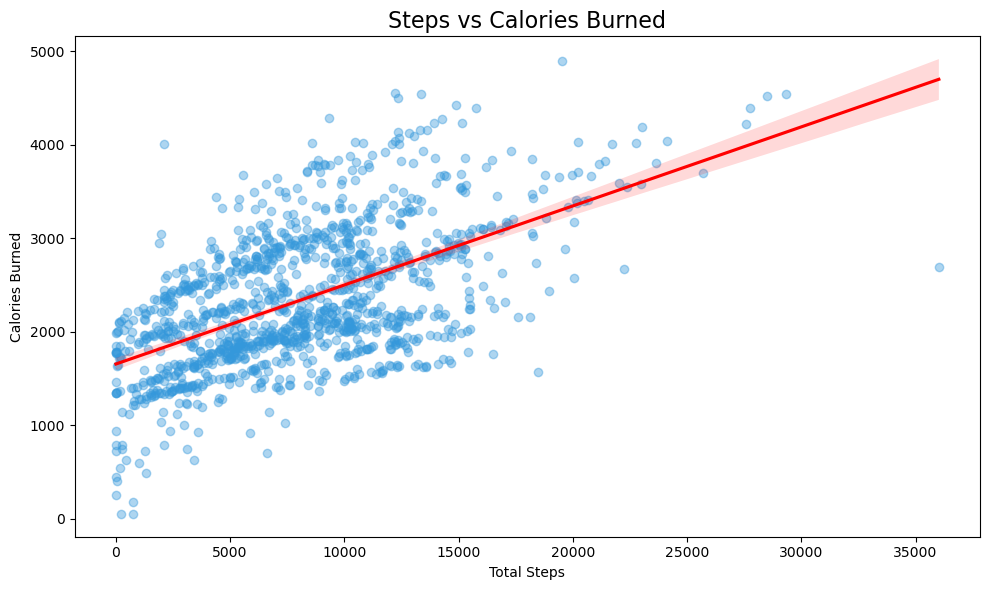

In [14]:
plt.figure(figsize=(10, 6))
sns.regplot(data=activity, x='TotalSteps', y='Calories', 
            scatter_kws={'alpha':0.4, 'color':'#3498db'},
            line_kws={'color':'red'})
plt.title('Steps vs Calories Burned', fontsize=16)
plt.xlabel('Total Steps')
plt.ylabel('Calories Burned')
plt.tight_layout()
plt.show()

In [15]:
# Merge activity and sleep data
activity['ActivityDate'] = pd.to_datetime(activity['ActivityDate'])
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])

merged = pd.merge(activity, sleep, 
                  left_on=['Id', 'ActivityDate'], 
                  right_on=['Id', 'SleepDay'])

print("Merged rows:", merged.shape[0])

Merged rows: 409


/tmp/ipykernel_161/492545194.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])


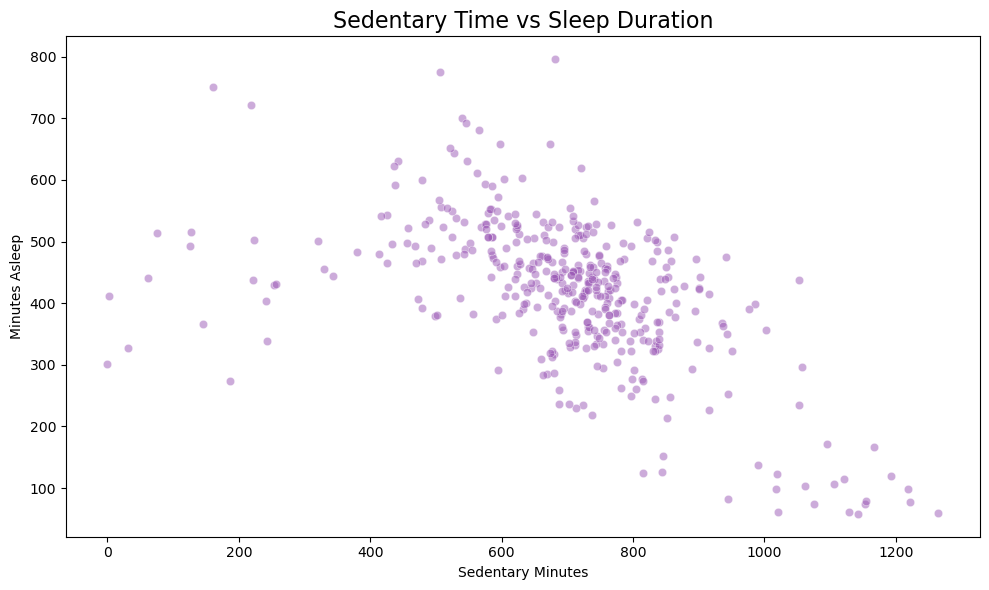

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged, x='SedentaryMinutes', y='TotalMinutesAsleep', 
                alpha=0.5, color='#9b59b6')
plt.title('Sedentary Time vs Sleep Duration', fontsize=16)
plt.xlabel('Sedentary Minutes')
plt.ylabel('Minutes Asleep')
plt.tight_layout()
plt.show()

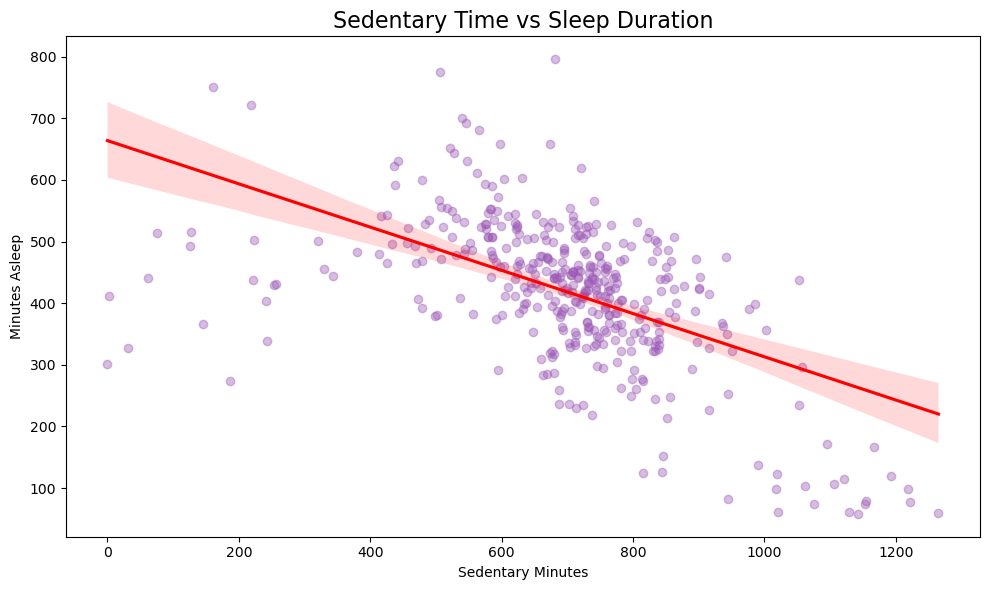

In [18]:
plt.figure(figsize=(10, 6))
sns.regplot(data=merged, x='SedentaryMinutes', y='TotalMinutesAsleep',
            scatter_kws={'alpha':0.4, 'color':'#9b59b6'},
            line_kws={'color':'red'})
plt.title('Sedentary Time vs Sleep Duration', fontsize=16)
plt.xlabel('Sedentary Minutes')
plt.ylabel('Minutes Asleep')
plt.tight_layout()
plt.show()